Dataset Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


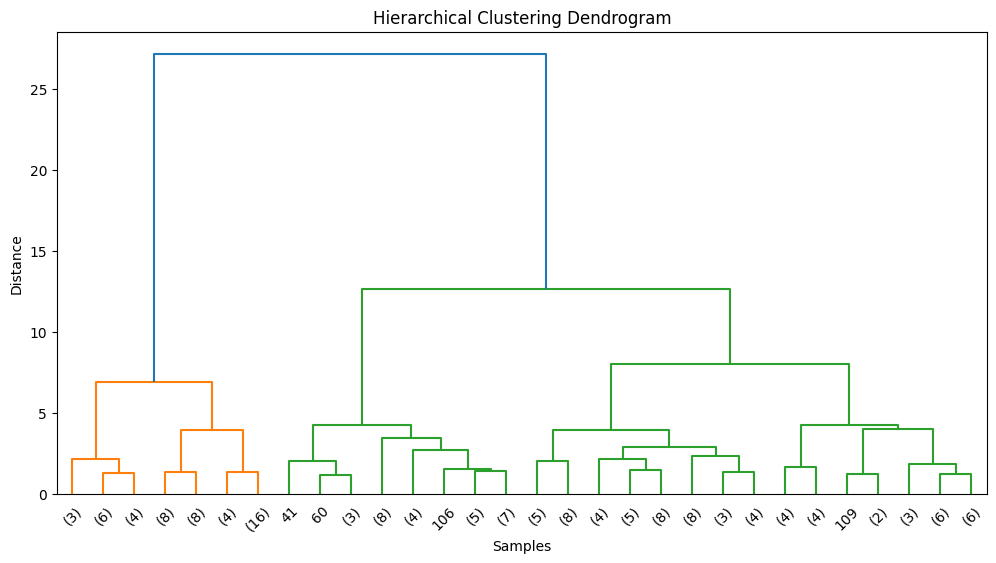

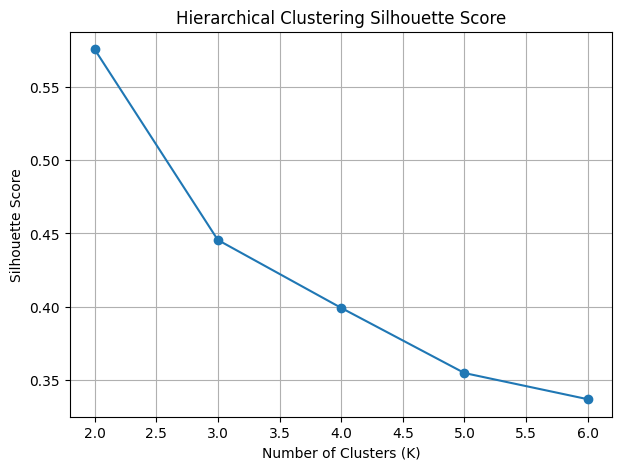

Best K: 2
Best Silhouette Score: 0.5753869579723335

Cluster Counts:
Hierarchical_Cluster
0    101
1     49
Name: count, dtype: int64


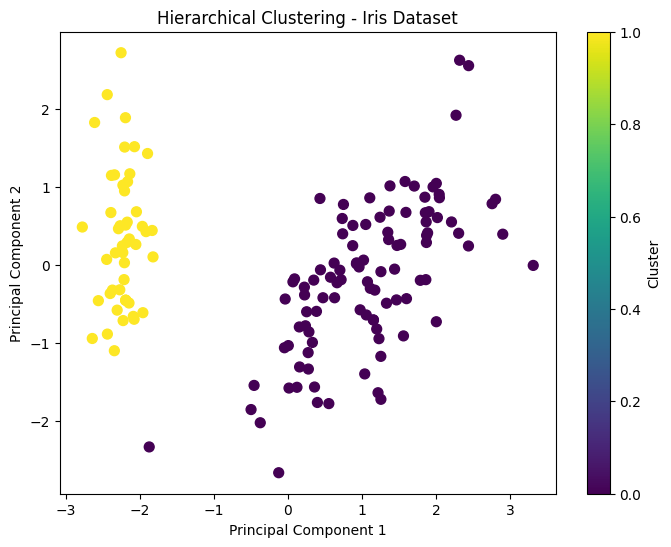


Cluster vs Species:
Species               Iris-setosa  Iris-versicolor  Iris-virginica
Hierarchical_Cluster                                              
0                               1               50              50
1                              49                0               0


In [1]:
# ============================================================
# HIERARCHICAL CLUSTERING - IRIS DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("/content/Iris (2).csv")

print("Dataset Shape:", df.shape)

display(df.head())

# ------------------------------------------------------------
# 2. Select Features
# ------------------------------------------------------------

features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

X = df[features]

# ------------------------------------------------------------
# 3. Standardization
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# 4. Dendrogram
# ------------------------------------------------------------

Z = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12,6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Samples")

plt.ylabel("Distance")

plt.show()

# ------------------------------------------------------------
# 5. Test Different Number of Clusters
# ------------------------------------------------------------

K = range(2, 7)

silhouette_scores = []

for k in K:

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

# ------------------------------------------------------------
# 6. Silhouette Score Graph
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

plt.plot(
    K,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title(
    "Hierarchical Clustering Silhouette Score"
)

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 7. Best K
# ------------------------------------------------------------

best_k = list(K)[
    np.argmax(silhouette_scores)
]

print("Best K:", best_k)

print(
    "Best Silhouette Score:",
    max(silhouette_scores)
)

# ------------------------------------------------------------
# 8. Final Hierarchical Model
# ------------------------------------------------------------

hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

clusters = hierarchical.fit_predict(X_scaled)

df["Hierarchical_Cluster"] = clusters

# ------------------------------------------------------------
# 9. Cluster Counts
# ------------------------------------------------------------

print("\nCluster Counts:")

print(
    df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 10. PCA Visualization
# ------------------------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title(
    "Hierarchical Clustering - Iris Dataset"
)

plt.colorbar(label="Cluster")

plt.show()

# ------------------------------------------------------------
# 11. Compare with Species
# ------------------------------------------------------------

print("\nCluster vs Species:")

print(
    pd.crosstab(
        df["Hierarchical_Cluster"],
        df["Species"]
    )
)